# Image classification models
## Dependencies

In [ ]:
""" %%capture
!cmd /c dependencies.bat """

### Imports


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time

In [2]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [4]:
random.seed(42)
tf.random.set_seed(42)

## Data


In [5]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [6]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']


In [7]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [8]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007
../capturas/capturas_256x256/capturasVR\Session_008
../capturas/capturas_256x256/capturasVR\Session_009
../capturas/capturas_256x256/capturasVR\Session_010
../capturas/capturas_256x256/capturasVR\Session_011
../capturas/capturas_256x256/capturasVR\Session_012
../capturas/capturas_256x256/capturasVR\Session_013
../capturas/capturas_256x256/capturasVR\Session_014
../capturas/capturas_256x256/capturasVR\Session_015
../capturas/capturas_256x256/capturasVR\Session_016
../capturas/capturas_256x256/capturasVR\Session_017


## Auxiliary functions

In [9]:
def get_paths_and_labels(df, test_size=0.2):
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['label'])
    
    paths = df_valid['full_path'].values
    labels = df_valid['label_encoded'].values
    
    # train test (80/20)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=test_size, random_state=42, stratify=labels
    )

    # train val (80/20)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder


def load_image_tf(path, label, method):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    
    if method == "resnet":
        img = tf.cast(img, tf.float32) / 255.0
    elif method == "efficientnet":
        img = tf.cast(img, tf.float32) 
    elif method == "mobilenet":
        img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img, label

In [21]:
augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
])

def augment_if_minority(image, label):
    clase_min = 2 # colocarSoporteSup
    
    image = tf.cond(
        tf.equal(label, clase_min),
        lambda: augment_layer(image, training=True),
        lambda: image
    )
    return image, label

In [11]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [12]:
def show_predictions_and_accuracy(y_pred_labels, test_images, y_true_labels, image_names, num_images=20):
  
    y_true = np.array(y_true_labels)
    y_pred = np.array(y_pred_labels)

    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(test_images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = test_images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"Real: {y_true[i]}\nPred: {y_pred[i]}\n{name}"
        if y_true[i] == y_pred[i]:
            plt.title(title, color="blue", fontsize=8)
        else:
            plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Calcular accuracy total
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

In [13]:
def plot_from_history(history, epochs):

    # Manejar tanto objeto history como dict directamente
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history

    acc = hist['accuracy']
    val_acc = hist['val_accuracy']

    loss = hist['loss']
    val_loss = hist['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [14]:
def save_history(history, nombre_archivo):
    with open(nombre_archivo, "wb") as f:
        pickle.dump(history.history, f)

def load_history(nombre_archivo):
    if os.path.exists(nombre_archivo):
        with open(nombre_archivo, "rb") as f:
            loaded_history = pickle.load(f)
        print(f"Historial cargado desde {nombre_archivo}.")
        return loaded_history
    else:
        print(f"No se encontró el archivo {nombre_archivo}.")
        return None

In [15]:
def training_pipeline_db(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Pesos para penalizar los errores al clasificar mal la clase minoritaria
    train_labels = np.concatenate([y for x, y in train_ds], axis=0)
    weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
    )

    # Crear un diccionario para Keras
    dict_weights = dict(enumerate(weights))
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    return test_acc, train_acc, train_loss, test_loss, history

In [16]:
def show_image_by_index(images, index):
  
    if index < 0 or index >= len(images):
        print(f"Índice {index} fuera de rango. El conjunto tiene {len(images)} imágenes.")
        return
    
    img = images[index].copy()  # Copiar para no modificar el original
    
    # Detectar si está preprocesada (valores fuera de [0,1] o negativos)
    if np.any(img < 0) or np.any(img > 1):
        # Asumir preprocesamiento de ResNet: revertir
        img = img + np.array([103.939, 116.779, 123.68])  # Sumar media
        img = img[:, :, ::-1]  # BGR a RGB
        img = img / 255.0  # Normalizar a [0,1]
        img = np.clip(img, 0, 1)  # Asegurar rango
    
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Imagen en índice {index}")
    plt.show()

## Get dataset

In [ ]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

['colocarNiquel' 'colocarPila' 'colocarSoporteSup' 'soldar']
Total: 7699
Entrenamiento: 4927
Validación:    1232
Test:          1540

Distribución de clases en el dataset completo:
label
colocarPila          3160
soldar               2276
colocarNiquel        2024
colocarSoporteSup     239
Name: count, dtype: int64
label
colocarPila          41.044291
soldar               29.562281
colocarNiquel        26.289128
colocarSoporteSup     3.104299
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20716\3835804295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


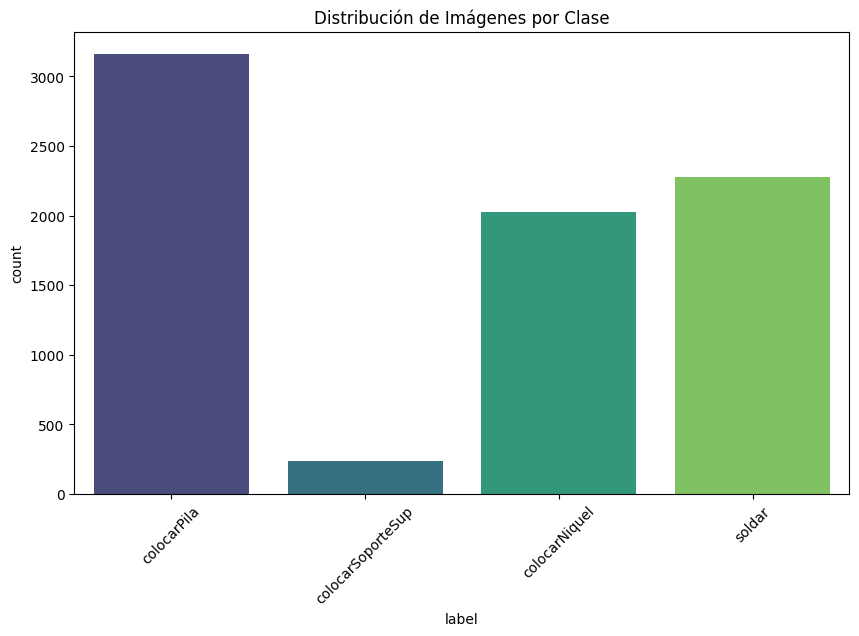

In [18]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribución de Imágenes por Clase')
plt.xticks(rotation=45)
plt.show()

In [19]:
resultados_tiempo = {}

## SOtA models

### ResNet50

Data augmentation se aplica solo en train porque test y val tienen que representar la realidad

In [20]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

TypeError: in user code:

    File "C:\Users\Usuario\AppData\Local\Temp\ipykernel_20716\3666949728.py", line 10, in augment_if_minority  *
        image = tf.cond(

    TypeError: Expected int64 passed to parameter 'y' of op 'Equal', got 'colocarSoporteSup' of type 'str' instead. Error: Expected int64, but got colocarSoporteSup of type 'str'.


In [ ]:
base_resnet50_db = ResNet50(
    weights = None,
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3),  # if include_top true input shape must be (224, 224, 3) 
    pooling = "avg"
)

model_resnet50_db = Sequential([
    base_resnet50_db,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_resnet50_db, train_acc_resnet50_db, train_loss_resnet50_db, test_loss_resnet50_db, history_resnet50_db = training_pipeline_db(model_resnet50_db, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_resnet50_db}\nTrain accuracy: {train_acc_resnet50_db}")
print(f"Test loss: {test_loss_resnet50_db}\nTrain loss: {train_loss_resnet50_db}")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1258s 8s/step - accuracy: 0.7215 - loss: 0.9123 - val_accuracy: 0.2955 - val_loss: 17.1383 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1229s 8s/step - accuracy: 0.9001 - loss: 0.2951 - val_accuracy: 0.5942 - val_loss: 2.0420 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1278s 8s/step - accuracy: 0.9255 - loss: 0.2289 - val_accuracy: 0.9562 - val_loss: 0.1933 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1276s 8s/step - accuracy: 0.9413 - loss: 0.1914 - val_accuracy: 0.4675 - val_loss: 3.6225 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1265s 8s/step - accuracy: 0.9507 - loss: 0.1613 - val_accuracy: 0.0942 - val_loss: 7.4091 - learning_rate: 0.0050
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9532 - loss: 0.1412
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
154/154 ━━━━━━━━━━━━━━━━━━━━ 1273s 8s/step - accuracy: 0.9594 - loss

218 minutos

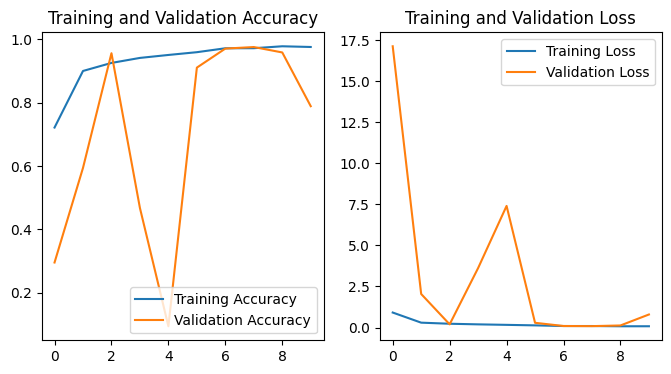

In [ ]:
plot_from_history(history_resnet50_db, epochs = epochs)

In [ ]:
model_resnet50_db.save("modelo_clas_proc_resnet50_db.keras")
save_history(history_resnet50_db, "history_resnet50_db.pkl")

In [ ]:
model_resnet50_db = load_model("modelo_clas_proc_resnet50_db.keras")
history_resnet50_db = load_history("history_resnet50_db.pkl")

In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_resnet50_db = model_resnet50_db.predict(test_ds)
y_pred_classes_resnet50_db = y_pred_resnet50_db.argmax(axis=1)
class_names = encoder.classes_ 

f1_resnet50_db = f1_score(y_true, y_pred_classes_resnet50_db, average="weighted")
print(f"F1 Score ResNet50 db: {f1_resnet50_db}")
print("-------------------------------------")

print("Classification Report ResNet50 db + no weights:")
print(classification_report(y_true, y_pred_classes_resnet50_db, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step
F1 Score ResNet50 db: 0.7839312376343103
-------------------------------------
Classification Report ResNet50 db + no weights:
                   precision    recall  f1-score   support

    colocarNiquel       0.77      0.60      0.68       405
      colocarPila       0.75      0.99      0.85       632
colocarSoporteSup       0.00      0.00      0.00        48
           soldar       0.94      0.80      0.87       455

         accuracy                           0.80      1540
        macro avg       0.62      0.60      0.60      1540
     weighted avg       0.79      0.80      0.78      1540



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [ ]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_resnet50_db)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print(" Perfecta! ✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f" Revisar ⚠️ (>25%)")
    else:
        print(" Estable OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1063  | 72    | 161   | 244   | Revisar ⚠️ (>25%)
colocarPila          | 698   | 210   | 7     | 625   | Revisar ⚠️ (>25%)
colocarSoporteSup    | 1492  | 0     | 48    | 0     | Revisar ⚠️ (>25%)
soldar               | 1062  | 23    | 89    | 366   | Estable OK
---------------------------------------------------------------------------


### EfficientNetB0 - Tensorflow

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

In [ ]:
start_time = time.time()

base_efficientNetB0 = EfficientNetB0(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_efficientNetB0 = Sequential([
    base_efficientNetB0,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10


test_acc_efficientNetB0, train_acc_efficientNetB0, train_loss_efficientNetB0, test_loss_efficientNetB0, history_efficientNetB0 = training_pipeline_db(model_efficientNetB0, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_efficientNetB0}\nTrain accuracy: {train_acc_efficientNetB0}")
print(f"Test loss: {test_loss_efficientNetB0}\nTrain loss: {train_loss_efficientNetB0}")

end_time = time.time()
training_time = end_time - start_time
resultados_tiempo['EfficientNetB0'] = training_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 846s 5s/step - accuracy: 0.9227 - loss: 0.2333 - val_accuracy: 0.2679 - val_loss: 7.0861 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 804s 5s/step - accuracy: 0.9501 - loss: 0.1550 - val_accuracy: 0.9594 - val_loss: 0.3542 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 806s 5s/step - accuracy: 0.9698 - loss: 0.1013 - val_accuracy: 0.9261 - val_loss: 0.3028 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 810s 5s/step - accuracy: 0.9685 - loss: 0.1054 - val_accuracy: 0.9570 - val_loss: 0.1484 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 808s 5s/step - accuracy: 0.9746 - loss: 0.0802 - val_accuracy: 0.9805 - val_loss: 0.1210 - learning_rate: 0.0050
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 823s 5s/step - accuracy: 0.9769 - loss: 0.0763 - val_accuracy: 0.9692 - val_loss: 0.1330 - learning_rate: 0.0050
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 820s 5s/step - accuracy: 0.9819 - loss: 0.

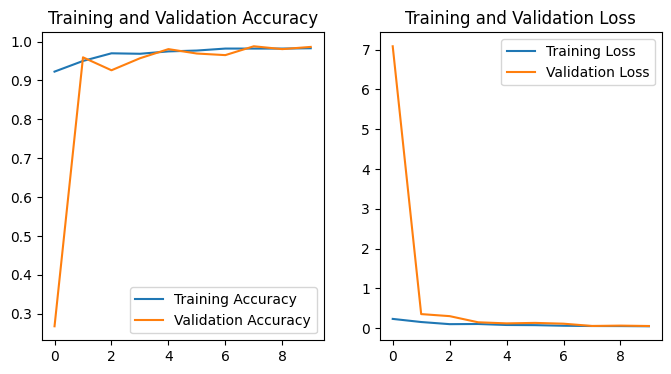

In [ ]:
plot_from_history(history_efficientNetB0, epochs = epochs)

##### Save model

In [ ]:
base_efficientNetB0.save("modelo_clas_proc_efficientNetB0.keras")
save_history(history_efficientNetB0, "history_efficientNetB0.pkl")

##### Load model

In [ ]:
base_efficientNetB0 = load_model("modelo_clas_proc_efficientNetB0.keras")
history_efficientNetB0 = load_history("history_efficientNetB0.pkl")

Historial cargado desde history_resnet50_imgnet.pkl.


#### Test

In [ ]:
y_pred_efficientNetB0 = model_efficientNetB0.predict(test_ds)

y_pred_classes_efficientNetB0 = y_pred_efficientNetB0.argmax(axis=1)

f1_efficientNetB0 = f1_score(y_true, y_pred_classes_efficientNetB0, average="weighted")
print(f"F1 Score EfficientNetB0: {f1_efficientNetB0}")
print("-------------------------------------")

print("Classification Report EfficientNetB0:")
print(classification_report(y_true, y_pred_classes_efficientNetB0, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 876ms/step
F1 Score EfficientNetB0: 0.9810591094199003
-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.98      0.97       405
      colocarPila       0.99      1.00      0.99       632
colocarSoporteSup       0.87      0.83      0.85        48
           soldar       0.99      0.98      0.98       455

         accuracy                           0.98      1540
        macro avg       0.96      0.95      0.95      1540
     weighted avg       0.98      0.98      0.98      1540



In [ ]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_efficientNetB0)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print(" Perfecta! ✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f" Revisar ⚠️ (>25%)")
    else:
        print(" Estable OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1124  | 11    | 10    | 395   | Estable OK
colocarPila          | 900   | 8     | 0     | 632   | Estable OK
colocarSoporteSup    | 1486  | 6     | 8     | 40    | Estable OK
soldar               | 1081  | 4     | 11    | 444   | Estable OK
---------------------------------------------------------------------------


### EfficientNetB7 - tensorflow

In [34]:
from tensorflow.keras.applications import EfficientNetB7

In [ ]:
base_efficientNetB7 = EfficientNetB7(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_efficientNetB7 = Sequential([
    base_efficientNetB7,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_efficientNetB7, train_acc_efficientNetB7, history_efficientNetB7 = training_pipeline(model_efficientNetB7, X_train_tensor, train_labels_encoded, X_test_tensor, test_labels_encoded, epochs = epochs)
print(f"Test accuracy: {test_acc_efficientNetB7}\nTrain accuracy: {train_acc_efficientNetB7}")

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7193s 164s/step - accuracy: 0.8635 - loss: 0.5226 - val_accuracy: 0.0296 - val_loss: 2579554.7500 - learning_rate: 0.0050
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6271s 146s/step - accuracy: 0.9236 - loss: 0.2831 - val_accuracy: 0.1006 - val_loss: 1296.8748 - learning_rate: 0.0050
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5915s 138s/step - accuracy: 0.9488 - loss: 0.1738 - val_accuracy: 0.4172 - val_loss: 5.7212 - learning_rate: 0.0050
Epoch 4/10
20/43 ━━━━━━━━━━━━━━━━━━━━ 51:09 133s/step - accuracy: 0.9333 - loss: 0.2174

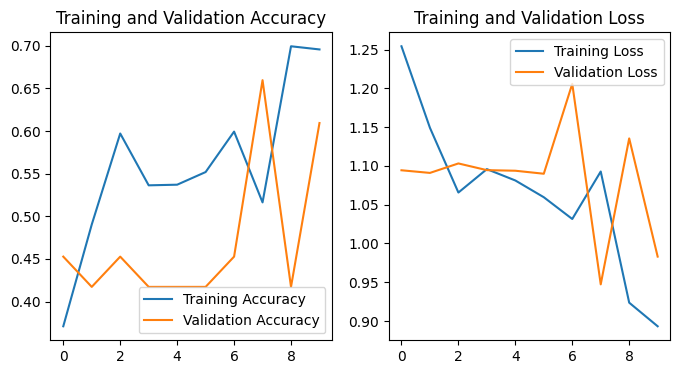

In [ ]:
plot_from_history(history_efficientNetB7, epochs = epochs)

##### Save model

In [ ]:
model_efficientNetB7.save("modelo_clas_proc_efficientNetB7.keras")
save_history(history_efficientNetB7, "history_efficientNetB7.pkl")

##### Load model

In [ ]:
model_efficientNetB7 = load_model("modelo_clas_proc_efficientNetB7.keras")
history_efficientNetB7 = load_history("history_efficientNetB7.pkl")

Historial cargado desde history_resnet50_imgnet.pkl.


#### Test

In [ ]:
y_pred_efficientNetB7 = model_efficientNetB7.predict(test_images)

y_pred_classes_efficientNetB7 = y_pred_efficientNetB7.argmax(axis=1)

f1_efficientNetB7 = f1_score(test_labels_encoded, y_pred_classes_efficientNetB7, average="weighted")
print(f"F1 Score EfficientNetB7: {f1_efficientNetB7}")
print("-------------------------------------")

cm_img = multilabel_confusion_matrix(test_labels_encoded, y_pred_classes_efficientNetB7)
print("Confusion Matrix EfficientNetB7:")
for i, matrix in enumerate(cm_img):
    print(f"Clase {i}: Pred + || Pred -  \n True + {matrix}\n")
print("-------------------------------------")

print("Classification Report EfficientNetB7:")
print(classification_report(test_labels_encoded, y_pred_classes_efficientNetB7, target_names=["colocarPila", "colocarSoporteSup", "colocarNiquel", "soldar"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step 
F1 Score EfficientNetB0: 0.5315761592064201
-------------------------------------
Confusion Matrix EfficientNetB0:
Clase 0: Pred + || Pred -  
 True + [[111 145]
 [ 20 146]]

Clase 1: Pred + || Pred -  
 True + [[409   0]
 [ 13   0]]

Clase 2: Pred + || Pred -  
 True + [[364   0]
 [ 58   0]]

Clase 3: Pred + || Pred -  
 True + [[207  30]
 [ 84 101]]

-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

      colocarPila       0.50      0.88      0.64       166
colocarSoporteSup       0.00      0.00      0.00        13
    colocarNiquel       0.00      0.00      0.00        58
           soldar       0.77      0.55      0.64       185

         accuracy                           0.59       422
        macro avg       0.32      0.36      0.32       422
     weighted avg       0.54      0.59      0.53       422



C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

### MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNet

In [ ]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

In [ ]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenet = Sequential([
    base_mobilenet,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_mobilenet = training_pipeline_db(model_mobilenet, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
resultados_tiempo['MobileNet'] = training_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.8918 - loss: 0.3317 - val_accuracy: 0.4107 - val_loss: 1.7638 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.9397 - loss: 0.1841 - val_accuracy: 0.2630 - val_loss: 1.6063 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 501s 3s/step - accuracy: 0.9594 - loss: 0.1331 - val_accuracy: 0.2955 - val_loss: 5.7963 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 501s 3s/step - accuracy: 0.9710 - loss: 0.1073 - val_accuracy: 0.9513 - val_loss: 0.1851 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.9754 - loss: 0.0867 - val_accuracy: 0.9700 - val_loss: 0.1022 - learning_rate: 0.0050
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.9732 - loss: 0.0944 - val_accuracy: 0.2630 - val_loss: 21.9591 - learning_rate: 0.0050
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step - accuracy: 0.9750 - loss: 0

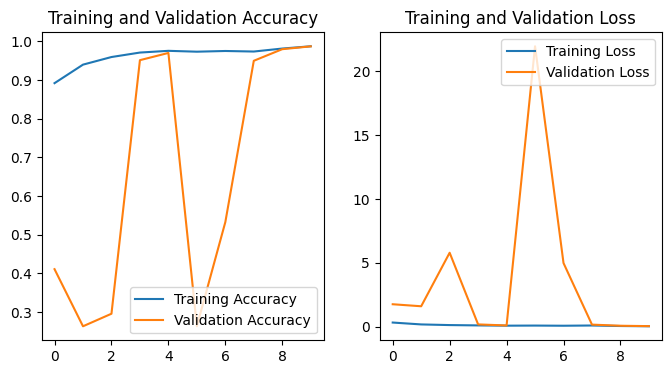

In [ ]:
plot_from_history(history_mobilenet, epochs = epochs)

In [ ]:
model_mobilenet.save("model_mobilenet.keras")
save_history(history_mobilenet, "history_mobilenet.pkl")

In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(y_true, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(y_true, y_pred_classes_mobilenet, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 534ms/step
F1 Score MobileNet: 0.9806929983625968
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.98      0.97      0.97       405
      colocarPila       0.99      0.99      0.99       632
colocarSoporteSup       0.83      0.92      0.87        48
           soldar       0.98      0.98      0.98       455

         accuracy                           0.98      1540
        macro avg       0.95      0.96      0.95      1540
     weighted avg       0.98      0.98      0.98      1540



In [ ]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_mobilenet)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print(" Perfecta! ✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f" Revisar ⚠️ (>25%)")
    else:
        print(" Estable OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1125  | 10    | 13    | 392   | Estable OK
colocarPila          | 904   | 4     | 5     | 627   | Estable OK
colocarSoporteSup    | 1483  | 9     | 4     | 44    | Estable OK
soldar               | 1078  | 7     | 8     | 447   | Estable OK
---------------------------------------------------------------------------


### Resultados 17 sesiones con data augmentation

| Modelo | Acc train | Acc test | Tiempo|
|----------|----------|----------|----------|
| ResNet   |          |          |          | 
| EfficientNetB0 |    |          |          |
| EfficientNetB7 |    |          |          |
| MobileNet   |       |          |          |
